# Example: Ticker-Picker Bandit

In this example, we put the Cobb-Douglas allocator and the combinatorial bandit on the same forward run. The pitch from class: *the Cobb-Douglas weights tell us how much of each ticker to hold; the bandit tells us which tickers belong in the basket in the first place.* This example wires those two stages together on real market data.

> __The problem in plain English__
>
> __What we are deciding.__ With $K = 22$ tickers we have $2^{22}-1 \approx 4.2$ million non-empty subsets. The bandit treats each subset as an arm and explores them with epsilon-greedy: with probability $\varepsilon_t$ pick a random subset, otherwise pick the subset with the highest running-average reward to date.
>
> __What the bandit gets back.__ For any candidate subset $\mathcal{S}$, we solve the analytical Cobb-Douglas allocation over those assets and return the resulting utility $U = \kappa(\boldsymbol\gamma_\mathcal{S})\,\prod_{s\in\mathcal{S}} n_s^{\gamma_s}$ as the reward, where $\gamma_s$ is the SIM-driven preference weight for ticker $s$ at the snapshot day. Higher $U$ means a more preferred portfolio.
>
> __How often we choose.__ The bandit picks the subset **once** at `BANDIT_DECISION_DATE`. After that, the subset is frozen and the Cobb-Douglas allocator handles the daily reweighting inside the basket. Task 3 then asks the natural follow-up: when should we re-fire the bandit and refresh the basket?
>
> __Which data we use.__ All real. SPY 2014-2024 training plus 2025-2026 YTD test gives us a ten-plus-year warmup for the EMAs and `gm_t`. Per-ticker prices come from the extended test OHLC dataset. There is no synthetic Monte Carlo and no bias-correction story; the forward path is what actually happened in the market.

The learning objectives below frame the three tasks that walk through the bandit pick, the forward Cobb-Douglas overlay, and the regime-triggered re-fire.

> __Learning Objectives:__
>
> By the end of this example, we will be able to:
> * __Run the combinatorial bandit on a real-data snapshot:__ Pick a basket of tickers at `BANDIT_DECISION_DATE` by running the epsilon-greedy bandit over all $2^K - 1$ subsets. Read the convergence plot to judge whether the iteration budget was sufficient.
> * __Forward-walk the Cobb-Douglas engine on the basket:__ With the basket frozen at the bandit's pick, run the daily Cobb-Douglas rebalancer forward on real prices and compare against the full-universe engine and an equal-weight buy-and-hold of the same basket. The comparison isolates the value of asset selection from daily reweighting.
> * __Re-fire the bandit on a regime trigger:__ Implement the sentiment trigger and re-run the bandit at each crossing, segmenting the forward path into intervals between fires. Run daily Cobb-Douglas inside each segment and compare the dynamic strategy against the static Task 2 baseline on the same realized path.

___

## Setup, Data and Prerequisites
We begin by loading our packages and helper functions via [the `Include.jl` file](./Include.jl). This activates the local [Julia](https://julialang.org) environment and loads all dependencies.

In [3]:
# --- Load packages and helper functions ---
include("Include.jl"); # The Include.jl file activates the local Julia environment and imports all dependencies.

### Constants
In the section below, we set the constants used throughout the notebook. Modify these to explore different baskets, decision days, and re-fire thresholds.

See the inline comments for units and roles.

In [5]:
# Ticker-picker configuration
B₀ = 10_000.0                       # starting budget (USD)
Δt = 1.0 / 252.0                    # trading-day step (years)
L_short = 21                        # short EMA window (days) for the sentiment crossover
L_long = 63                         # long EMA window (days) for the sentiment crossover
L_growth = 10                       # EMA window (days) for the rebalancing engine's daily allocator
GAIN = 10.0                         # gain constant G for the λ sentiment signal (dimensionless)
BANDIT_EPSILON = 0.1                # initial exploration probability for the epsilon-greedy bandit
BANDIT_ALPHA = 0.1                  # constant learning rate for bandit arm-mean updates
BANDIT_ITERS_SINGLE = 500           # bandit iteration budget for the Task 1 pick
BANDIT_DECISION_DATE = "2025-01-02"  # the calendar day we treat as "now" for the bandit; bandit fires once on this day
BANDIT_GM_WINDOW     = 63            # EMA window (days) for the long-run market-growth estimate fed to the bandit
TRIGGER_MAX_DRAWDOWN = 0.15         # drawdown trigger threshold (de-risks to cash, fraction)
TRIGGER_MAX_TURNOVER = 0.50         # max fraction of wealth traded per rebalance
RETRIGGER_LAMBDA_THRESH = 0.25      # |λ_t| threshold for the Task 3 re-fire trigger

0.25

### Implementation
We define three helpers used by the tasks below:

* A notebook-local override of `eCornellAIFinance.bandit_world(action, context)` matching the canonical world function from the [INFORMS-Annual-Meeting-2025-BanditPoster](https://github.com/varnerlab/INFORMS-Annual-Meeting-2025-BanditPoster).
* `run_segment(...)` runs the Cobb-Douglas rebalancing engine on a slice of the forward window with a chosen basket and starting wealth; Task 3 calls it once per segment between re-fires.
* `realized_metrics(W)` returns terminal wealth, max drawdown, annualized return, and Sharpe from a wealth path; used by the Task 2 and Task 3 scorecards.

> __`bandit_world(action, context)`: action-set utility (canonical INFORMS form)__
>
> Let $\mathcal{S} = \{i : a_i = 1\}$. Compute $\gamma_i = \tanh(\alpha_i / \beta_i^{\lambda} + \beta_i^{1-\lambda}\,\mathbb{E}[g_m])$ from the SIM regime lens (no hard mask), allocate over $\mathcal{S}$ via the lecture's analytical Cobb-Douglas solution, then return $U = \kappa(\boldsymbol\gamma_{\mathcal{S}}) \, \prod_{i \in \mathcal{S}} n_i^{\gamma_i}$ with $\kappa = +1$ if all $\gamma_i \geq 0$ on $\mathcal{S}$ else $-1$. Excluded assets contribute nothing.

The segment runner consumes those allocations as its per-bar starting state.

> __`run_segment(B_start, basket, day_start, day_end)`__
>
> Build a `MyRebalancingContextModel` over the slice `forward_price_matrix[day_start:day_end, ...]` for the chosen `basket`, with starting budget `B_start` and the standard trigger rules, then run the Cobb-Douglas engine. Returns the wealth path on the segment. Reads the global forward arrays `forward_price_matrix`, `forward_lambda`, `forward_gm_ema`, the universe `my_tickers`, and `sim_params`.

The metrics helper aggregates the resulting wealth path into the realized scorecard fields.

> __`realized_metrics(W)`__
>
> Returns a NamedTuple with `W_T`, `W_T_over_W0`, `max_dd`, `ann_ret`, and `sharpe` computed from a wealth path `W::Vector{Float64}`. Reads the global `B₀` and `g_f`.

The helper definitions appear in the code blocks below.

In [7]:
function eCornellAIFinance.bandit_world(action::Array{Int,1},
        context::MyBanditContext)::Tuple{Float64,Array{Float64,1},Array{Float64,1}}
    K = length(context.tickers);
    B = context.B;
    ε = context.epsilon;
    p = context.prices;

    # --- Step 1: Natural preference weights (no hard mask) ---
    γ = compute_preference_weights(context.sim_parameters, context.tickers,
            context.gm_t, context.lambda);

    # --- Step 2: Action set S = { i : action[i] == 1 } ---
    S = findall(==(1), action);
    n = zeros(K);
    if isempty(S)
        return (0.0, n, γ);
    end

    # --- Step 3: Cobb-Douglas allocation over S (canonical INFORMS form) ---
    negative_gamma_flag = any(γ[S] .< 0);
    if negative_gamma_flag == false
        γ̄ = sum(γ[S]);
        for s in S
            n[s] = (γ[s] / γ̄) * (B / p[s]);
        end
    else
        B̄ = B;
        γ̄ = 0.0;
        for s in S
            if γ[s] < 0.0
                B̄ -= ε * p[s];
                n[s] = ε;
            else
                γ̄ += γ[s];
            end
        end
        if γ̄ > 0.0
            for s in S
                if γ[s] ≥ 0.0
                    n[s] = (γ[s] / γ̄) * (B̄ / p[s]);
                end
            end
        end
    end

    # --- Step 4: Reward U = κ · prod_{i ∈ S} n_i^{γ_i} ---
    κ = negative_gamma_flag ? -1.0 : 1.0;
    U = κ;
    for s in S
        U *= n[s]^γ[s];
    end

    return (U, n, γ);
end;

In [8]:
function run_segment(B_start::Float64, basket::Vector{String},
        day_start::Int, day_end::Int)::Vector{Float64}
    # --- Step 1: Slice the forward arrays and SIM params for the chosen basket ---
    sel_idx     = findall(in(basket), my_tickers);
    sel_sim     = Dict(t => sim_params[t] for t in basket);
    sel_pmat    = forward_price_matrix[day_start:day_end, vcat([1], sel_idx .+ 1)];
    sub_lambda  = forward_lambda[day_start:day_end];
    sub_gm_ema  = forward_gm_ema[day_start:day_end];
    n_seg       = day_end - day_start + 1;

    # --- Step 2: Single-day segment is a no-op (no trading occurs) ---
    if n_seg < 2
        return [B_start];
    end

    # --- Step 3: Build context + rules and run the CD engine on the segment ---
    ctx = build(MyRebalancingContextModel, (
        B = B_start, tickers = basket, marketdata = sel_pmat,
        marketfactor = sub_gm_ema, sim_parameters = sel_sim,
        lambda = sub_lambda[1], Δt = Δt, epsilon = 0.1
    ));
    rules_seg = build(MyTriggerRules, (
        max_drawdown = TRIGGER_MAX_DRAWDOWN,
        max_turnover = TRIGGER_MAX_TURNOVER,
        rebalance_schedule = ones(Int, n_seg - 1)
    ));
    res = run_rebalancing_engine(ctx, rules_seg, sub_lambda; offset = 1, allocator = :cobb_douglas);
    return compute_wealth_series(res, sel_pmat, basket; offset = 1);
end;

In [9]:
function realized_metrics(W::Vector{Float64})
    # --- Step 1: Per-day returns and the running peak for drawdown ---
    ret  = diff(W) ./ W[1:end-1];
    peak = accumulate(max, W);

    # --- Step 2: Aggregate metrics ---
    max_dd  = maximum((peak .- W) ./ peak);
    vol     = std(ret) * sqrt(252);
    ann_ret = log(W[end] / W[1]) * (252.0 / (length(W) - 1));
    sharpe  = vol > 1e-6 ? (ann_ret - g_f) / vol : 0.0;

    return (W_T = W[end], W_T_over_W0 = W[end] / B₀, max_dd = max_dd,
            ann_ret = ann_ret, sharpe = sharpe);
end;

Load Session 1 artifacts and the real OHLC datasets we will use throughout. The cell concatenates the 2014-2024 training SPY series with the 2025-2026 YTD test SPY series, finds `BANDIT_DECISION_DATE` in the combined timeline, computes $\lambda_t$ and $\mathbb{E}[g_m]$ at that day, and pre-computes the forward arrays needed by Task 2's CD engine.

The cell returns:

* `my_tickers::Vector{String}`: ticker universe loaded from the Session 1 calibration.
* `sim_estimates::Vector{MySIMParameterEstimate}`: per-ticker SIM fits (α, β, σ_ε with bootstrap SEs).
* `sim_params::Dict{String,Tuple{Float64,Float64,Float64}}`: allocator-adapter view of `sim_estimates`, keyed by ticker.
* `g_f::Float64`: continuously compounded annual risk-free rate (1/yr).
* `N::Int`: number of tickers in the universe.
* `bandit_decision_date::DateTime`: the resolved decision day from `BANDIT_DECISION_DATE`.
* `bandit_λ::Float64`, `bandit_gm_t::Float64`, `bandit_prices::Vector{Float64}`: single-snapshot inputs to the Task 1 bandit context.
* `forward_dates::Vector{DateTime}`, `forward_price_matrix::Matrix{Float64}`, `forward_lambda::Vector{Float64}`, `forward_gm_ema::Vector{Float64}`: forward arrays from `BANDIT_DECISION_DATE` through 2026-04-22, used by Task 2's CD engine.
* `forward_gm_ema_bandit::Vector{Float64}`: 63-day EMA of `compute_market_growth` over the same forward window, used as `gm_t` when Task 3 re-fires the bandit on a regime crossing.

In [11]:
(; my_tickers, sim_estimates, sim_params, g_f, N,
   bandit_decision_date, bandit_λ, bandit_gm_t, bandit_prices,
   forward_dates, forward_price_matrix, forward_lambda, forward_gm_ema, forward_gm_ema_bandit) = let
    using Dates, DataFrames

    # --- Step 1: Load S1 artifacts ---
    minvar = load_results(joinpath(_PATH_TO_DATA_S1, "minvar-allocation.jld2"));
    my_tickers    = minvar["my_tickers"]::Vector{String};
    sim_estimates = minvar["sim_estimates"];
    g_f           = haskey(minvar, "g_f") ? Float64(minvar["g_f"]) : Float64(minvar["r_f"]);
    sim_params = Dict{String,Tuple{Float64,Float64,Float64}}(
        e.ticker => (e.α, e.β, e.σ_ε) for e in sim_estimates
    );
    N = length(my_tickers);

    # --- Step 2: Real SPY history (training + extended test) ---
    train_spy = MyTrainingMarketDataSet()["dataset"]["SPY"];
    test_spy  = MyExtendedTestingMarketDataSet()["dataset"]["SPY"];
    spy_full  = vcat(train_spy, test_spy);
    sort!(spy_full, :timestamp);
    unique!(spy_full, :timestamp);

    target_date = Date(BANDIT_DECISION_DATE);
    bandit_decision_t = findfirst(==(target_date), Date.(spy_full.timestamp));
    isnothing(bandit_decision_t) && error("BANDIT_DECISION_DATE=\$(BANDIT_DECISION_DATE) not found in SPY history");
    bandit_decision_date = spy_full.timestamp[bandit_decision_t];

    # --- Step 3: λ and gm_t for the Task 1 bandit context (snapshot at decision day) ---
    spy_history = spy_full.close[1:bandit_decision_t];
    ema_s_real  = compute_ema(spy_history; window = L_short);
    ema_l_real  = compute_ema(spy_history; window = L_long);
    λ_real      = compute_lambda(ema_s_real, ema_l_real; G = GAIN);
    gm_real     = compute_market_growth(spy_history; Δt = Δt);
    gm_ema_real = compute_ema(gm_real; window = BANDIT_GM_WINDOW);
    bandit_λ    = λ_real[end];
    bandit_gm_t = gm_ema_real[end];

    # --- Step 4: Per-ticker prices on the decision day ---
    test_ds   = MyExtendedTestingMarketDataSet()["dataset"];
    bandit_prices = zeros(N);
    for (k, t) in enumerate(my_tickers)
        df = test_ds[t];
        i  = findfirst(==(target_date), Date.(df.timestamp));
        isnothing(i) && error("ticker \$(t) missing close on \$(target_date)");
        bandit_prices[k] = df.close[i];
    end

    # --- Step 5: Forward arrays (decision day → end of test data) for Task 2's CD engine ---
    # SPY EMAs and engine's gm_ema (10-day window) on the FULL training+test history,
    # then sliced to the forward window so the engine has stable inputs from day 1.
    ema_s_full   = compute_ema(spy_full.close; window = L_short);
    ema_l_full   = compute_ema(spy_full.close; window = L_long);
    λ_full       = compute_lambda(ema_s_full, ema_l_full; G = GAIN);
    gm_full      = compute_market_growth(spy_full.close; Δt = Δt);     # length spy_full - 1
    gm_ema_full  = compute_ema(gm_full; window = L_growth);             # 10-day for daily engine
    gm_ema_bandit_full = compute_ema(gm_full; window = BANDIT_GM_WINDOW);  # 63-day for bandit re-fires (Task 3)

    n_full          = length(spy_full.close);
    forward_dates   = spy_full.timestamp[bandit_decision_t:end];        # length n_fwd
    n_fwd           = length(forward_dates);

    forward_lambda  = λ_full[bandit_decision_t:end];                    # length n_fwd
    forward_gm_ema  = gm_ema_full[bandit_decision_t-1:end];             # length n_fwd
    forward_gm_ema_bandit = gm_ema_bandit_full[bandit_decision_t-1:end]; # length n_fwd, used by Task 3 re-fires

    forward_price_matrix = zeros(n_fwd, N + 1);
    forward_price_matrix[:, 1] = 1:n_fwd;
    target_dates_fwd = Date.(forward_dates);
    for (k, t) in enumerate(my_tickers)
        df = test_ds[t];
        df_dates = Date.(df.timestamp);
        for (day, d) in enumerate(target_dates_fwd)
            i = findfirst(==(d), df_dates);
            isnothing(i) && error("ticker \$(t) missing close on \$(d)");
            forward_price_matrix[day, k + 1] = df.close[i];
        end
    end

    println("Loaded \$(N) tickers (\$(2^N - 1) possible subsets)")
    println("Bandit decision day: \$(Date(bandit_decision_date))")
    println("  gm_t = \$(round(bandit_gm_t, digits=3)) /yr  (\$(BANDIT_GM_WINDOW)-day EMA of compute_market_growth)")
    println("  λ    = \$(round(bandit_λ, digits=3))      (EMA crossover \$(L_short) / \$(L_long))")
    println("Forward window: \$(Date(forward_dates[1])) → \$(Date(forward_dates[end]))  (\$(n_fwd) trading days)")

    (my_tickers = my_tickers, sim_estimates = sim_estimates, sim_params = sim_params,
     g_f = g_f, N = N,
     bandit_decision_date = bandit_decision_date,
     bandit_λ = bandit_λ, bandit_gm_t = bandit_gm_t, bandit_prices = bandit_prices,
     forward_dates = forward_dates, forward_price_matrix = forward_price_matrix,
     forward_lambda = forward_lambda, forward_gm_ema = forward_gm_ema,
     forward_gm_ema_bandit = forward_gm_ema_bandit)
end;

Loaded $(N) tickers ($(2^N - 1) possible subsets)
Bandit decision day: $(Date(bandit_decision_date))
  gm_t = $(round(bandit_gm_t, digits=3)) /yr  ($(BANDIT_GM_WINDOW)-day EMA of compute_market_growth)
  λ    = $(round(bandit_λ, digits=3))      (EMA crossover $(L_short) / $(L_long))
Forward window: $(Date(forward_dates[1])) → $(Date(forward_dates[end]))  ($(n_fwd) trading days)


___
## Task 1: Bandit Picks the Basket
In this task, we run the bandit on a single real-market snapshot. The constant `BANDIT_DECISION_DATE` (default 2025-01-02) is the calendar day we treat as **"now"**. The bandit fires once on this day and picks one subset of the 22 tickers; that subset becomes the **basket** for Task 2's forward Cobb-Douglas run.

The bandit context is built from the inputs the loader cell prepared from real data: `bandit_λ` (EMA crossover at the decision day), `bandit_gm_t` (63-day EMA of `compute_market_growth`, used as the long-run $\mathbb{E}[g_m]$), and `bandit_prices` (the 22 tickers' actual closing prices on the decision day). We then run [`solve_bandit(...)`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.solve_bandit) over all $2^K - 1$ arms.

> __What should we see?__
>
> Sensible (non-saturated) preference weights $\gamma_i \in (-1, 1)$ for the 22 tickers and a reward trace that climbs as the bandit discovers the best subset. The chosen subset should bias toward tickers with the highest SIM-driven $\gamma_i$ at the snapshot.

The code block below returns `bandit_result::`[`MyBanditResult`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.MyBanditResult) and `selected_tickers::Vector{String}` (the basket Task 2 will use).

Task 1 bandit decision day: 2025-01-02
Best subset (1 of 22 assets):
  ["NFLX"]
  Utility: 1.4577


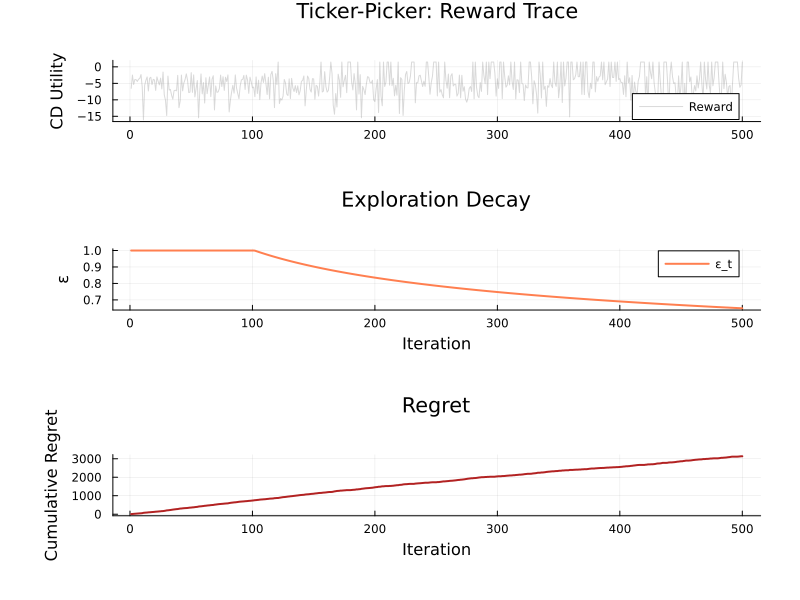

In [13]:
(; bandit_result, selected_tickers) = let
    # --- Step 1: Build the bandit context from real-data inputs ---
    bandit_ctx = build(MyBanditContext, (
        tickers = my_tickers, sim_parameters = sim_params,
        prices = bandit_prices, B = B₀,
        gm_t = bandit_gm_t, lambda = bandit_λ, epsilon = BANDIT_EPSILON
    ));

    # --- Step 2: Run the combinatorial bandit ---
    bandit_model = build(MyEpsilonGreedyBanditModel, (
        K = N, n_iterations = BANDIT_ITERS_SINGLE, alpha = BANDIT_ALPHA
    ));
    bandit_result = solve_bandit(bandit_model, bandit_ctx);

    # --- Step 3: Report ---
    selected = bandit_result.best_action;
    selected_tickers = my_tickers[selected .== 1];
    println("Task 1 bandit decision day: $(Date(bandit_decision_date))")
    println("Best subset ($(length(selected_tickers)) of $(N) assets):")
    println("  $(selected_tickers)")
    println("  Utility: $(round(bandit_result.best_utility, digits=4))")

    # --- Step 4: Visualize convergence ---
    p1 = plot(bandit_result.reward_history, alpha=0.3, color=:gray50, label="Reward",
        ylabel="CD Utility", title="Ticker-Picker: Reward Trace");
    p2 = plot(bandit_result.exploration_history, color=:coral, lw=2, label="ε_t",
        ylabel="ε", xlabel="Iteration", title="Exploration Decay");
    regret = compute_regret(bandit_result.reward_history);
    p3 = plot(regret, color=:firebrick, lw=2, label="",
        ylabel="Cumulative Regret", xlabel="Iteration", title="Regret");
    display(plot(p1, p2, p3, layout=(3,1), size=(800, 600), margin = 8Plots.mm, bottom_margin = 10Plots.mm, left_margin = 12Plots.mm))
    (bandit_result = bandit_result, selected_tickers = selected_tickers)
end;

___
## Task 2: Forward CD Rebalancing on the Basket (Real Data)
In this task, we forward-walk the Cobb-Douglas rebalancing engine from `BANDIT_DECISION_DATE` through 2026-04-22 (≈330 trading days) on **real** prices, with the basket frozen at Task 1's pick. We compare three strategies on the same forward path:

* __Bandit + CD:__ Daily Cobb-Douglas rebalancing within `selected_tickers`. The combined strategy.
* __Full-Universe CD:__ Daily Cobb-Douglas rebalancing across all 22 tickers, no basket selection. Isolates the bandit's contribution.
* __Bandit + BH:__ Equal-weight buy-and-hold of `selected_tickers` at the decision day, no rebalancing. Isolates the CD allocator's contribution.

> __What should we see?__
>
> The Bandit + CD strategy benefits both from basket selection (excluding low-γ assets at the decision day) and from daily reweighting (responding to evolving λ_t and gm_ema). Whether the combination beats either ablation alone is a property of the realized market path; in a steadily bullish stretch, basket selection is more valuable than rebalancing, and in a regime change rebalancing matters more.

The code block below returns `forward_results::Dict{String,Vector{Float64}}` mapping each strategy label to its wealth path on the forward window, plus `forward_summary::DataFrame` with realized terminal wealth, max drawdown, and annualized Sharpe.

In [15]:
(; forward_results, forward_summary) = let
    # --- Step 1: Resolve the basket and SIM params for the bandit-selected subset ---
    K_sel = length(selected_tickers);
    selected_idx = findall(in(selected_tickers), my_tickers);
    sel_sim_params = Dict(t => sim_params[t] for t in selected_tickers);
    sel_price_matrix = forward_price_matrix[:, vcat([1], selected_idx .+ 1)];

    n_fwd = size(forward_price_matrix, 1);
    T_trade = n_fwd - 1;

    # --- Step 2: Bandit + CD (engine on selected_tickers) ---
    ctx_bandit = build(MyRebalancingContextModel, (
        B = B₀, tickers = selected_tickers, marketdata = sel_price_matrix,
        marketfactor = forward_gm_ema, sim_parameters = sel_sim_params,
        lambda = forward_lambda[1], Δt = Δt, epsilon = 0.1
    ));
    rules = build(MyTriggerRules, (
        max_drawdown = TRIGGER_MAX_DRAWDOWN, max_turnover = TRIGGER_MAX_TURNOVER,
        rebalance_schedule = ones(Int, T_trade)
    ));
    res_bandit = run_rebalancing_engine(ctx_bandit, rules, forward_lambda;
        offset = 1, allocator = :cobb_douglas);
    wealth_bandit = compute_wealth_series(res_bandit, sel_price_matrix, selected_tickers; offset = 1);

    # --- Step 3: Full-Universe CD (engine on all 22 tickers) ---
    ctx_full = build(MyRebalancingContextModel, (
        B = B₀, tickers = my_tickers, marketdata = forward_price_matrix,
        marketfactor = forward_gm_ema, sim_parameters = sim_params,
        lambda = forward_lambda[1], Δt = Δt, epsilon = 0.1
    ));
    res_full = run_rebalancing_engine(ctx_full, rules, forward_lambda;
        offset = 1, allocator = :cobb_douglas);
    wealth_full = compute_wealth_series(res_full, forward_price_matrix, my_tickers; offset = 1);

    # --- Step 4: Bandit + BH (equal-weight on selected basket, no rebalancing) ---
    p0 = sel_price_matrix[1, 2:end];
    shares_bh = (B₀ / K_sel) ./ p0;
    wealth_bh = zeros(n_fwd);
    for d in 1:n_fwd
        wealth_bh[d] = sum(shares_bh .* sel_price_matrix[d, 2:end]);
    end

    # --- Step 5: Build the per-strategy summary using realized_metrics from Implementation ---
    m_bandit = realized_metrics(wealth_bandit);
    m_full   = realized_metrics(wealth_full);
    m_bh     = realized_metrics(wealth_bh);
    forward_summary = DataFrame(
        "Strategy"        => ["Bandit + CD", "Full-Universe CD", "Bandit + BH"],
        "Tickers"         => [K_sel, N, K_sel],
        "W_T (\$)"        => [round(m.W_T, digits = 0) for m in (m_bandit, m_full, m_bh)],
        "W_T / W₀"        => [round(m.W_T_over_W0, digits = 3) for m in (m_bandit, m_full, m_bh)],
        "Max DD (%)"      => [round(m.max_dd * 100, digits = 1) for m in (m_bandit, m_full, m_bh)],
        "Ann. return (%)" => [round(m.ann_ret * 100, digits = 2) for m in (m_bandit, m_full, m_bh)],
        "Sharpe"          => [round(m.sharpe, digits = 3) for m in (m_bandit, m_full, m_bh)],
    );

    forward_results = Dict(
        "Bandit + CD"      => wealth_bandit,
        "Full-Universe CD" => wealth_full,
        "Bandit + BH"      => wealth_bh,
    );
    (forward_results = forward_results, forward_summary = forward_summary)
end;

The code block below renders the per-strategy scorecard for the forward run from `BANDIT_DECISION_DATE` through the end of the available real OHLC.

In [17]:
let
    println("Real forward run: $(Date(forward_dates[1])) → $(Date(forward_dates[end]))  ($(length(forward_dates)) trading days)")
    pretty_table(forward_summary; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

Real forward run: 2025-01-02 → 2026-04-22  (326 trading days)
 ------------------ --------- --------- ---------- ------------ ----------------- ---------
          Strategy   Tickers   W_T ($)   W_T / W₀   Max DD (%)   Ann. return (%)    Sharpe 
            String     Int64   Float64    Float64      Float64           Float64   Float64 
 ------------------ --------- --------- ---------- ------------ ----------------- ---------
       Bandit + CD         1   12035.0      1.204         15.4             14.37      0.54
  Full-Universe CD        22   11228.0      1.123         11.9              8.98     0.392
       Bandit + BH         1   10515.0      1.052         43.4              3.89    -0.017
 ------------------ --------- --------- ---------- ------------ ----------------- ---------


The code block below plots the three forward wealth paths on a common timeline, scaled to $W/W_0$, with a reference line at 1.0.

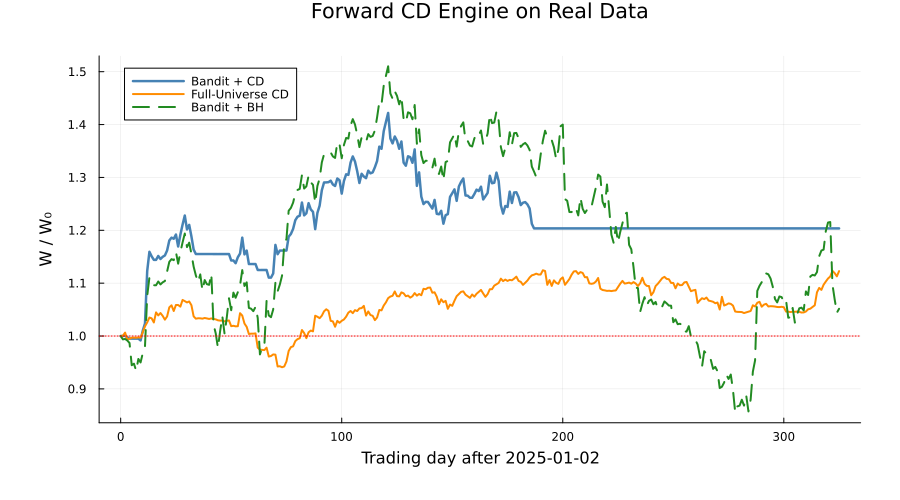

In [19]:
let
    # --- Panel 1: Forward wealth trajectories on real data ---
    plt = plot(xlabel = "Trading day after $(Date(bandit_decision_date))",
               ylabel = "W / W₀", title = "Forward CD Engine on Real Data",
               legend = :topleft, size = (900, 500), margin = 8Plots.mm, bottom_margin = 10Plots.mm, left_margin = 12Plots.mm);
    style = Dict(
        "Bandit + CD"      => (color = :steelblue,  lw = 2.5),
        "Full-Universe CD" => (color = :darkorange, lw = 2.0),
        "Bandit + BH"      => (color = :forestgreen, lw = 2.0, linestyle = :dash),
    );
    for label in ["Bandit + CD", "Full-Universe CD", "Bandit + BH"]
        W = forward_results[label];
        plot!(plt, 0:(length(W)-1), W ./ B₀; label = label, style[label]...);
    end
    hline!(plt, [1.0], color = :red, linestyle = :dot, label = "");
    display(plt)
end

___
## Task 3: Re-Firing the Bandit on a Regime Trigger
In this task, we relax the static-basket assumption by re-firing the bandit on regime crossings. The bandit fired once on `BANDIT_DECISION_DATE` and the basket has been frozen since. That is fine in steady regimes; it is wrong when the world changes underneath us. Candidate triggers for refreshing the basket include:

* __Sentiment regime shift:__ $|\lambda_t| > \theta$. Cheap, model-free, fires when momentum flips.
* __Drawdown breach:__ portfolio drawdown crosses a threshold. Ties the re-fire to bad outcomes rather than changing inputs.
* __Periodic recalibration:__ every $N$ trading days. Simple baseline; misses regime shifts.
* __Preference-vector divergence:__ recompute $\gamma_i$ at the current day; re-fire on cosine distance from the last decision-day $\gamma_i$. More principled, heavier.

We implement the sentiment trigger: every crossing of $|\lambda_t| = \theta$ (`RETRIGGER_LAMBDA_THRESH`, default 0.25), in either direction, re-runs the bandit at that day's market state and resumes Cobb-Douglas rebalancing on the new basket. Wealth carries continuously across segment boundaries. The result is a __dynamic__ Bandit + CD strategy we compare against the __static__ Bandit + CD from Task 2.

> __What should we see?__
>
> Wealth and $\lambda_t$ on a shared timeline with vertical markers at each re-fire day. Dynamic equals static between fires and diverges after each one. Whether dynamic beats static is path-dependent.

In [21]:
(; dynamic_results) = let
    θ = RETRIGGER_LAMBDA_THRESH;
    n_fwd = length(forward_lambda);

    # --- Step 1: Detect every crossing of the |λ_t| = θ boundary (any regime transition) ---
    # Fires both on outward crossings (entering an extreme regime) and on inward
    # crossings (returning to neutral), since the bandit's γ_i depends on λ_t and
    # both directions change the basket's preferences materially.
    prev_above = abs(forward_lambda[1]) > θ;
    fire_idx = Int[];
    for t in 2:n_fwd
        cur_above = abs(forward_lambda[t]) > θ;
        if cur_above != prev_above
            push!(fire_idx, t);
        end
        prev_above = cur_above;
    end

    # --- Step 2: For each fire day, run the bandit at that day's market state ---
    baskets = [selected_tickers];
    for fire_t in fire_idx
        fire_ctx = build(MyBanditContext, (
            tickers = my_tickers, sim_parameters = sim_params,
            prices = forward_price_matrix[fire_t, 2:end], B = B₀,
            gm_t = forward_gm_ema_bandit[fire_t],
            lambda = forward_lambda[fire_t], epsilon = BANDIT_EPSILON
        ));
        fire_model = build(MyEpsilonGreedyBanditModel, (
            K = N, n_iterations = BANDIT_ITERS_SINGLE, alpha = BANDIT_ALPHA
        ));
        fire_result = solve_bandit(fire_model, fire_ctx);
        push!(baskets, my_tickers[fire_result.best_action .== 1]);
    end

    # --- Step 3: Walk forward by segment, switching basket at each fire ---
    boundaries = vcat([1], fire_idx, [n_fwd + 1]);
    wealth_dynamic = zeros(n_fwd);
    W_running      = B₀;

    for k in 1:length(boundaries)-1
        seg_start = boundaries[k];
        seg_end   = boundaries[k+1] - 1;
        seg_wealth = run_segment(W_running, baskets[k], seg_start, seg_end);
        wealth_dynamic[seg_start:seg_end] .= seg_wealth;
        W_running = seg_wealth[end];
    end

    # --- Step 4: Per-fire log (text output) ---
    if isempty(fire_idx)
        println("No |λ_t| > $(θ) crossings on the forward path; dynamic = static.")
    else
        println("Re-fired bandit on $(length(fire_idx)) day(s):")
        for (i, t) in enumerate(fire_idx)
            new_basket = baskets[i + 1];
            println("  day $(t-1)  ($(Date(forward_dates[t])))  λ = $(round(forward_lambda[t], digits=3))  →  basket = $(length(new_basket)) tickers: $(new_basket)")
        end
    end

    dynamic_results = Dict(
        "wealth_dynamic" => wealth_dynamic,
        "fire_idx"       => fire_idx,
        "baskets"        => baskets,
    );
    (dynamic_results = dynamic_results,)
end;

Re-fired bandit on 4 day(s):
  day 63  (2025-04-04)  λ = 0.288  →  basket = 3 tickers: ["NFLX", "COST", "CVX"]
  day 82  (2025-05-02)  λ = 0.238  →  basket = 11 tickers: ["DIS", "NFLX", "AMZN", "HD", "TJX", "COST", "HON", "AAPL", "MSFT", "NVDA", "AVGO"]
  day 120  (2025-06-27)  λ = -0.252  →  basket = 14 tickers: ["NFLX", "AMZN", "TJX", "CVX", "JPM", "MA", "ABBV", "HON", "AAPL", "NVDA", "AVGO", "CRM", "SHW", "AMT"]
  day 194  (2025-10-13)  λ = -0.245  →  basket = 13 tickers: ["DIS", "NFLX", "AMZN", "MA", "UNH", "HON", "AAPL", "MSFT", "NVDA", "AVGO", "CRM", "SHW", "AMT"]


The code block below builds the scorecard comparing the four strategies on the forward path: the static and dynamic Bandit + CD strategies plus the two Task 2 baselines (Full-Universe CD, Bandit + BH).

In [23]:
let
    m_static = realized_metrics(forward_results["Bandit + CD"]);
    m_dyn    = realized_metrics(dynamic_results["wealth_dynamic"]);
    m_full   = realized_metrics(forward_results["Full-Universe CD"]);
    m_bh     = realized_metrics(forward_results["Bandit + BH"]);

    scorecard = DataFrame(
        "Strategy"          => ["Bandit + CD (static)", "Bandit + CD (dynamic)",
                                "Full-Universe CD", "Bandit + BH"],
        "Re-fires"          => [0, length(dynamic_results["fire_idx"]), 0, 0],
        "W_T (\$)"          => [round(m.W_T, digits=0) for m in (m_static, m_dyn, m_full, m_bh)],
        "W_T / W₀"          => [round(m.W_T_over_W0, digits=3) for m in (m_static, m_dyn, m_full, m_bh)],
        "Max DD (%)"        => [round(m.max_dd * 100, digits=1) for m in (m_static, m_dyn, m_full, m_bh)],
        "Ann. return (%)"   => [round(m.ann_ret * 100, digits=2) for m in (m_static, m_dyn, m_full, m_bh)],
        "Sharpe"            => [round(m.sharpe, digits=3) for m in (m_static, m_dyn, m_full, m_bh)],
    );
    pretty_table(scorecard; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 ----------------------- ---------- --------- ---------- ------------ ----------------- ---------
               Strategy   Re-fires   W_T ($)   W_T / W₀   Max DD (%)   Ann. return (%)    Sharpe 
                 String      Int64   Float64    Float64      Float64           Float64   Float64 
 ----------------------- ---------- --------- ---------- ------------ ----------------- ---------
   Bandit + CD (static)          0   12035.0      1.204         15.4             14.37      0.54
  Bandit + CD (dynamic)          4   11436.0      1.144         17.7              10.4     0.381
       Full-Universe CD          0   11228.0      1.123         11.9              8.98     0.392
            Bandit + BH          0   10515.0      1.052         43.4              3.89    -0.017
 ----------------------- ---------- --------- ---------- ------------ ----------------- ---------


The code block below renders a two-panel figure: (top) the four wealth trajectories on the same forward window with vertical markers at each re-fire day, (bottom) the forward $\lambda_t$ trace with the $\pm \theta$ threshold bands and the same re-fire markers.

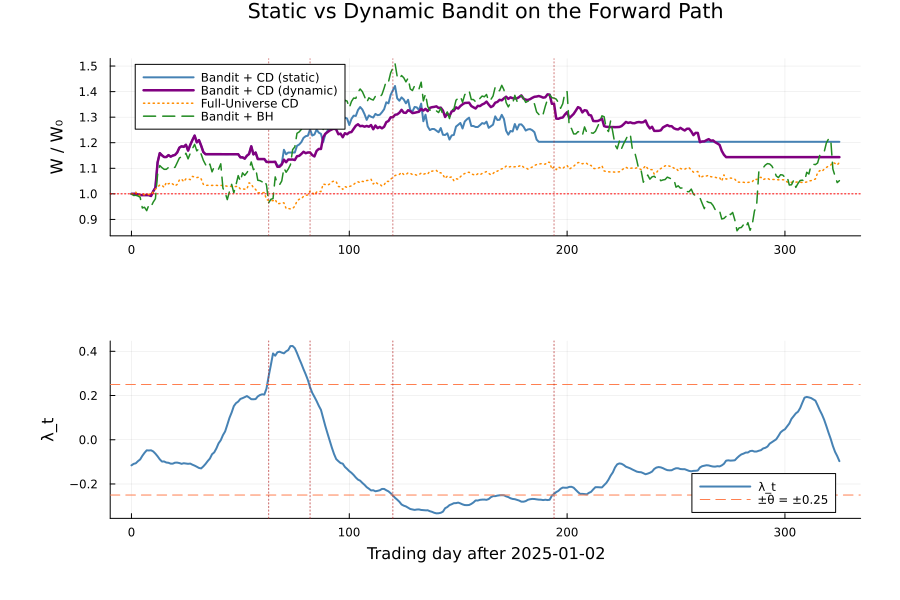

In [25]:
let
    n_fwd = length(forward_lambda);
    θ = RETRIGGER_LAMBDA_THRESH;
    fire_idx = dynamic_results["fire_idx"];
    wealth_dynamic = dynamic_results["wealth_dynamic"];

    p_top = plot(xlabel = "", ylabel = "W / W₀",
                 title = "Static vs Dynamic Bandit on the Forward Path",
                 legend = :topleft, size = (900, 250), margin = 8Plots.mm, bottom_margin = 10Plots.mm, left_margin = 12Plots.mm);
    plot!(p_top, 0:(n_fwd-1), forward_results["Bandit + CD"]      ./ B₀; color = :steelblue,   lw = 2.0, label = "Bandit + CD (static)");
    plot!(p_top, 0:(n_fwd-1), wealth_dynamic                       ./ B₀; color = :purple,      lw = 2.5, label = "Bandit + CD (dynamic)");
    plot!(p_top, 0:(n_fwd-1), forward_results["Full-Universe CD"]  ./ B₀; color = :darkorange,  lw = 1.5, label = "Full-Universe CD", linestyle = :dot);
    plot!(p_top, 0:(n_fwd-1), forward_results["Bandit + BH"]       ./ B₀; color = :forestgreen, lw = 1.5, label = "Bandit + BH",     linestyle = :dash);
    hline!(p_top, [1.0]; color = :red, linestyle = :dot, label = "");
    for t in fire_idx
        vline!(p_top, [t-1]; color = :firebrick, linestyle = :dot, alpha = 0.6, label = "");
    end

    p_bot = plot(0:(n_fwd-1), forward_lambda; lw = 2, color = :steelblue,
                 xlabel = "Trading day after $(Date(bandit_decision_date))",
                 ylabel = "λ_t", legend = :bottomright,
                 label = "λ_t", size = (900, 250), margin = 8Plots.mm, bottom_margin = 10Plots.mm, left_margin = 12Plots.mm);
    hline!(p_bot, [θ, -θ]; color = :coral, linestyle = :dash, label = "±θ = ±$(θ)");
    for t in fire_idx
        vline!(p_bot, [t-1]; color = :firebrick, linestyle = :dot, alpha = 0.7, label = "");
    end

    display(plot(p_top, p_bot, layout = (2, 1), size = (900, 600), margin = 8Plots.mm, bottom_margin = 10Plots.mm, left_margin = 12Plots.mm))
end

___
## Summary
This advanced example wired the combinatorial epsilon-greedy bandit and the Cobb-Douglas rebalancing engine into a two-stage pipeline on real S&P 500 data. The bandit decides the basket at a single decision day, and the Cobb-Douglas engine handles daily reweighting inside the basket on the realized forward path.

> __Key Takeaways:__
>
> * __Two-stage allocation:__ The bandit answers _what's in the basket_ and the Cobb-Douglas allocator answers _how much of each item to hold_. The two stages are complementary; the bandit handles a discrete combinatorial decision the analytical allocator cannot.
> * __Real data sidesteps the synthetic-MC bias-correction story:__ Running the engine forward on actual prices removes the rebalancing-alpha artifact entirely. The trade-off is one realized path instead of a distribution; conclusions about _did the strategy work_ carry the variance of a single market outcome.
> * __Closed-loop refresh works:__ A static bandit pick at the decision day freezes the basket through any regime change; the sentiment trigger ($|\lambda_t| > \theta$) re-runs the bandit at each crossing and switches the basket on the fly. Whether dynamic beats static on the realized path is data-dependent, but the closed-loop variant is the version that scales into Session 4's production cron.

Task 3's forward $\lambda_t$ plot is the bridge into the Session 4 production discussion: the same trigger logic can sit behind a real Alpaca paper account, calling the bandit on a schedule or on regime crossings rather than once at a chosen calendar day.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use real historical data and simplified models.

___